In [14]:
from pathlib import Path
import os

# Aller automatiquement à la racine du projet si on est dans runs/ ou notebooks/
root = Path(__file__).resolve().parents[1] if '__file__' in globals() else Path.cwd().parents[0]
os.chdir(root)
print("Projet initialisé depuis :", os.getcwd())


Projet initialisé depuis : C:\Machine Learning\projet


In [15]:
# ...existing code...
import pandas as pd
from pathlib import Path

repo_root = Path.cwd().resolve().parent if False else Path("C:/Machine Learning/projet/projet-machine-learning")  # leave for context
mapping_csv = Path("labels_image_mapping.csv")
if not mapping_csv.exists():
    mapping_csv = repo_root / "labels_image_mapping.csv"

map_df = pd.read_csv(mapping_csv)
train_map = map_df[map_df["split"] == "train"].copy()
print("Labels train:", len(train_map))

rows = []
for _, r in train_map.iterrows():
    label_path = Path(r["label_path"])
    img_path = r["image_path"]
    if not Path(img_path).exists():
        img_path = None
    if not label_path.exists():
        continue
    with open(label_path, "r") as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]
    if not lines:
        # image has no annotation lines -> keep row with zero boxes if desired
        rows.append({"file": label_path.stem, "image_path": img_path, "class_id": None, "x_center": None, "y_center": None, "width": None, "height": None})
    else:
        for line in lines:
            parts = line.split()
            if len(parts) >= 5:
                cls, xc, yc, w, h = parts[:5]
                rows.append({"file": label_path.stem, "image_path": img_path, "class_id": int(cls), "x_center": float(xc), "y_center": float(yc), "width": float(w), "height": float(h)})

df_files = pd.DataFrame(rows)
print("Total annotations (train):", len(df_files))
print("Images annotées (train):", df_files["file"].nunique())
# ...existing code...

Labels train: 1386
Total annotations (train): 4426
Images annotées (train): 1386


In [16]:
from pathlib import Path
import subprocess

file_path = "dataset/labels/train/gss1006_jpg.rf.4af59454602ed9949a31b4c6d32377ef.txt"

# détecter la racine git si possible, sinon parent
try:
    repo_root = Path(subprocess.check_output(["git","rev-parse","--show-toplevel"], stderr=subprocess.DEVNULL).decode().strip())
except Exception:
    repo_root = Path.cwd().resolve().parent

candidates = []
p = Path(file_path)
# 1) chemin relatif depuis cwd
candidates.append(Path.cwd() / p)
# 2) chemin depuis la racine du repo
candidates.append(repo_root / p)
# 3) recherche globale par nom
candidates += list(repo_root.rglob(p.name))

# trouver le premier existant
found = None
for c in candidates:
    if c and c.exists():
        found = c
        break

if not found:
    print("Fichier introuvable. Chemins testés (ex.) :")
    for c in candidates[:6]:
        print("-", c)
else:
    print("Ouvert :", found)
    with open(found, "r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()
    print("Nombre de lignes :", len(lines))
    print("5 premières lignes :")
    for L in lines[:5]:
        print(L.rstrip())

Ouvert : C:\Machine Learning\projet\projet-machine-learning\dataset\labels\train\gss1006_jpg.rf.4af59454602ed9949a31b4c6d32377ef.txt
Nombre de lignes : 1
5 premières lignes :
1 0.0625 0.5347222222222222 0.023958333333333335 0.06388888888888888


In [17]:
import os
print("Dossier courant :", os.getcwd())


Dossier courant : C:\Machine Learning\projet


In [18]:
import os

# ✅ Change le dossier courant vers la racine du projet
os.chdir(r"C:\Machine Learning\projet\projet-machine-learning")

# Vérifie :
print("Nouveau dossier courant :", os.getcwd())


Nouveau dossier courant : C:\Machine Learning\projet\projet-machine-learning


In [19]:
import pandas as pd

file_path = r"dataset\labels\train\gss1006_jpg.rf.4af59454602ed9949a31b4c6d32377ef.txt"

with open(file_path, "r", encoding="utf-8") as f:
    lines = [l.strip() for l in f if l.strip()]

df = pd.DataFrame(
    [line.split() for line in lines],
    columns=["class_id", "x_center", "y_center", "width", "height"]
)

# Convertir les types
df = df.astype({
    "class_id": int,
    "x_center": float,
    "y_center": float,
    "width": float,
    "height": float
})

print("✅ Fichier lu avec succès :", file_path)
print(df.head())


✅ Fichier lu avec succès : dataset\labels\train\gss1006_jpg.rf.4af59454602ed9949a31b4c6d32377ef.txt
   class_id  x_center  y_center     width    height
0         1    0.0625  0.534722  0.023958  0.063889


In [20]:
# 1. Charger toutes les annotations dans un DataFrame
import glob
import pandas as pd

label_files = glob.glob("dataset/labels/train/*.txt")
all_data = []

for file_path in label_files:
    with open(file_path, "r") as f:
        lines = f.readlines()
        for line in lines:
            all_data.append(line.strip().split())

df = pd.DataFrame(all_data, columns=["class_id", "x_center", "y_center", "width", "height"])
df = df.astype({"class_id": int, "x_center": float, "y_center": float, "width": float, "height": float})

# 2. Statistiques descriptives et qualité des données
print("Statistiques descriptives :")
print(df.describe())
print("\nValeurs manquantes :")
print(df.isnull().sum())
print("\nValeurs hors [0,1] :")
for col in ["x_center", "y_center", "width", "height"]:
    print(f"{col}: {(df[col] < 0).sum()} négatives")



Statistiques descriptives :
          class_id     x_center     y_center        width       height
count  4424.000000  4424.000000  4424.000000  4424.000000  4424.000000
mean      2.977848     0.507190     0.417453     0.024860     0.054621
std       1.547487     0.241525     0.241041     0.018852     0.030241
min       0.000000     0.012760     0.013889     0.003646     0.009259
25%       2.000000     0.311133     0.212037     0.012500     0.033333
50%       3.000000     0.497135     0.393981     0.019531     0.046296
75%       5.000000     0.694336     0.573264     0.031250     0.066667
max       5.000000     0.996615     0.988889     0.181771     0.249074

Valeurs manquantes :
class_id    0
x_center    0
y_center    0
width       0
height      0
dtype: int64

Valeurs hors [0,1] :
x_center: 0 négatives
y_center: 0 négatives
width: 0 négatives
height: 0 négatives


In [21]:
# Compter le nombre d'annotations pour chaque classe
class_counts = df["class_id"].value_counts()
print("Nombre d'annotations par classe :")
print(class_counts)

Nombre d'annotations par classe :
class_id
5    1265
2    1096
1     907
3     698
4     414
0      44
Name: count, dtype: int64


In [22]:
# Calculer la corrélation entre les variables numériques
correlations = df[["x_center", "y_center", "width", "height"]].corr()
print("Corrélations entre les variables :")
print(correlations)

Corrélations entre les variables :
          x_center  y_center     width    height
x_center  1.000000  0.013895 -0.013330 -0.092006
y_center  0.013895  1.000000  0.417356  0.207733
width    -0.013330  0.417356  1.000000  0.576489
height   -0.092006  0.207733  0.576489  1.000000


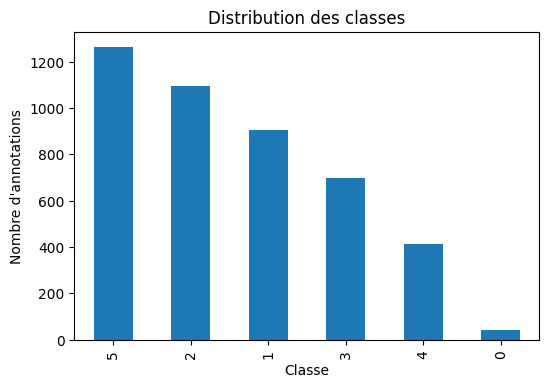

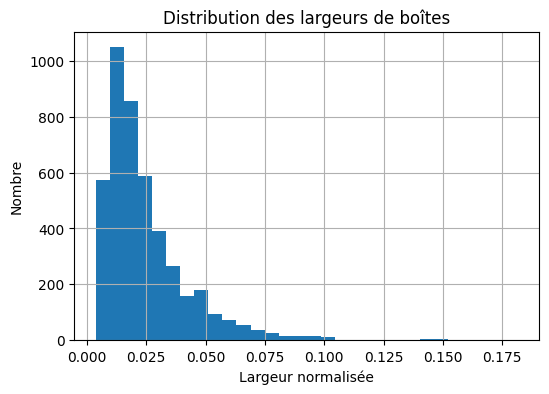

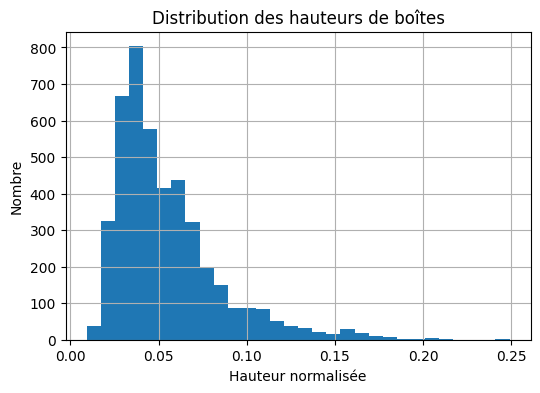

In [24]:
import matplotlib.pyplot as plt

# Visualiser la distribution des classes
plt.figure(figsize=(6,4))
class_counts.plot(kind="bar")
plt.title("Distribution des classes")
plt.xlabel("Classe")
plt.ylabel("Nombre d'annotations")
plt.show()

# Visualiser la distribution des largeurs de boîtes
plt.figure(figsize=(6,4))
df["width"].hist(bins=30)
plt.title("Distribution des largeurs de boîtes")
plt.xlabel("Largeur normalisée")
plt.ylabel("Nombre")
plt.show()

# Visualiser la distribution des hauteurs de boîtes
plt.figure(figsize=(6,4))
df["height"].hist(bins=30)
plt.title("Distribution des hauteurs de boîtes")
plt.xlabel("Hauteur normalisée")
plt.ylabel("Nombre")
plt.show()

Statistiques des boîtes par classe :
             width                                            height  \
              mean    median       min       max       std      mean   
class_id                                                               
0         0.021070  0.014844  0.005729  0.082292  0.016367  0.063552   
1         0.017993  0.015625  0.003646  0.074479  0.010342  0.057448   
2         0.041134  0.034896  0.007292  0.181771  0.026069  0.058110   
3         0.021826  0.019792  0.004167  0.076042  0.011696  0.040827   
4         0.024347  0.021615  0.006771  0.083854  0.011713  0.049378   
5         0.017656  0.014063  0.003646  0.069271  0.011305  0.058586   

                                                  
            median       min       max       std  
class_id                                          
0         0.052778  0.030556  0.160185  0.033305  
1         0.053704  0.023148  0.182407  0.025629  
2         0.043519  0.009259  0.213889  0.038620  
3       

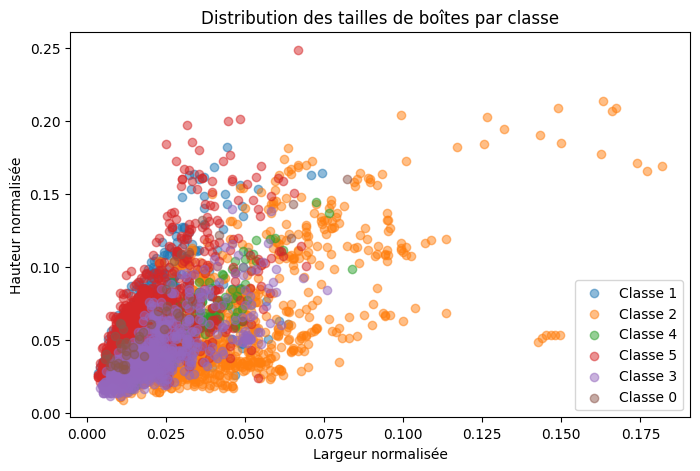

In [25]:
# Calculer des statistiques par classe
stats_par_classe = df.groupby("class_id")[["width", "height"]].agg(["mean", "median", "min", "max", "std"])
print("Statistiques des boîtes par classe :")
print(stats_par_classe)

# Visualiser la distribution des tailles de boîtes pour chaque classe
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
for cls in df["class_id"].unique():
    subset = df[df["class_id"] == cls]
    plt.scatter(subset["width"], subset["height"], label=f"Classe {cls}", alpha=0.5)
plt.xlabel("Largeur normalisée")
plt.ylabel("Hauteur normalisée")
plt.title("Distribution des tailles de boîtes par classe")
plt.legend()
plt.show()

In [26]:
# ...existing code...

from pathlib import Path

def check_train_annotations():
    base = Path("dataset")
    img_dir = base / "images" / "train"
    lbl_dir = base / "labels" / "train"
    image_exts = {".jpg", ".jpeg", ".png", ".bmp"}

    imgs = [p for p in img_dir.iterdir() if p.suffix.lower() in image_exts] if img_dir.exists() else []
    txts = list(lbl_dir.glob("*.txt")) if lbl_dir.exists() else []

    img_bases = {p.stem for p in imgs}
    txt_bases = {p.stem for p in txts}

    only_images = sorted(img_bases - txt_bases)
    only_labels = sorted(txt_bases - img_bases)

    print("=== Train split ===")
    print(f"Images (train): {len(imgs)}")
    print(f".txt (train):   {len(txts)}")
    print(f"Images sans .txt: {len(only_images)}", f"(ex.: {only_images[:10]})" if only_images else "")
    print(f".txt sans image:  {len(only_labels)}", f"(ex.: {only_labels[:10]})" if only_labels else "")
    if len(only_images) == 0 and len(only_labels) == 0:
        print("Tous les fichiers image ont leur .txt correspondant et inversement.")
    else:
        print("Vérifie les fichiers listés ci-dessus et corrige les noms ou supprime les éléments orphelins.")

    return {
        "n_images": len(imgs),
        "n_txts": len(txts),
        "images_without_txt": only_images,
        "txts_without_image": only_labels
    }

# Exécution
res = check_train_annotations()

# ...existing code...

=== Train split ===
Images (train): 1386
.txt (train):   1386
Images sans .txt: 0 
.txt sans image:  0 
Tous les fichiers image ont leur .txt correspondant et inversement.


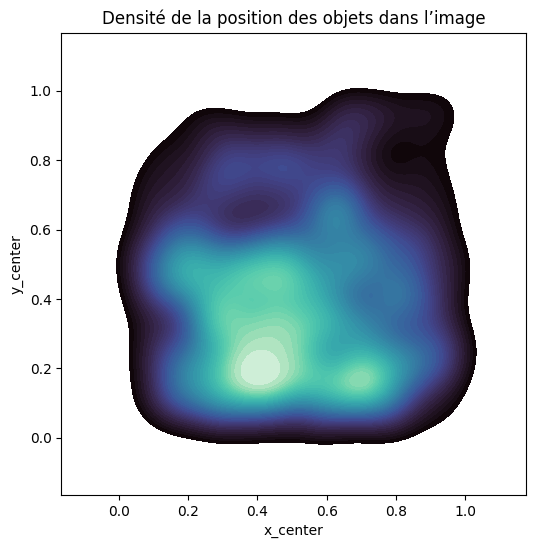

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
sns.kdeplot(
    x=df["x_center"], y=df["y_center"],
    fill=True, cmap="mako", thresh=0.05, levels=50
)
plt.title("Densité de la position des objets dans l’image")
plt.xlabel("x_center")
plt.ylabel("y_center")
plt.show()


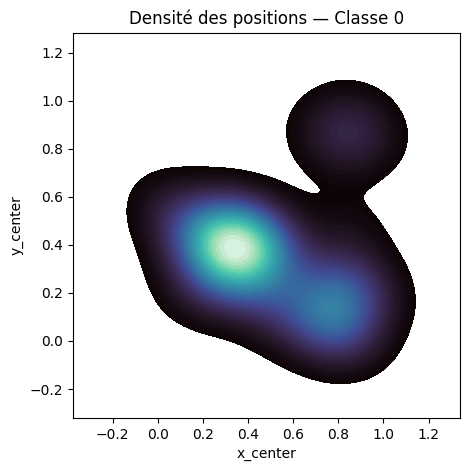

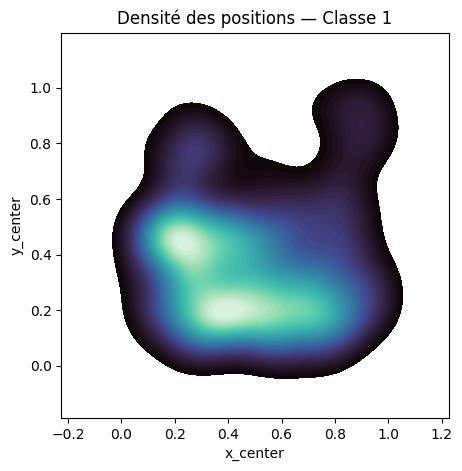

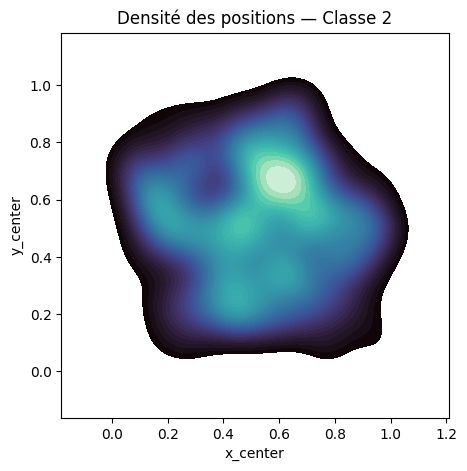

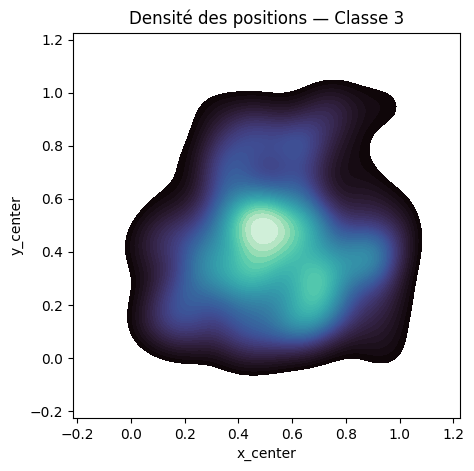

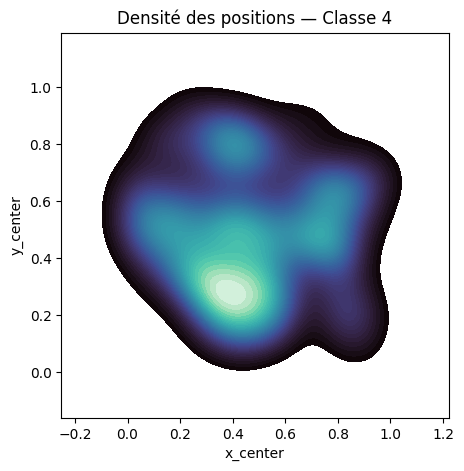

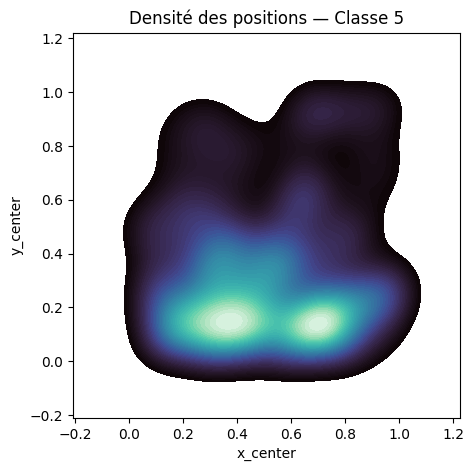

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

for cls in sorted(df["class_id"].unique()):
    subset = df[df["class_id"] == cls]
    plt.figure(figsize=(5,5))
    sns.kdeplot(
        x=subset["x_center"], y=subset["y_center"],
        fill=True, cmap="mako", thresh=0.05, levels=50
    )
    plt.title(f"Densité des positions — Classe {cls}")
    plt.xlabel("x_center")
    plt.ylabel("y_center")
    plt.show()


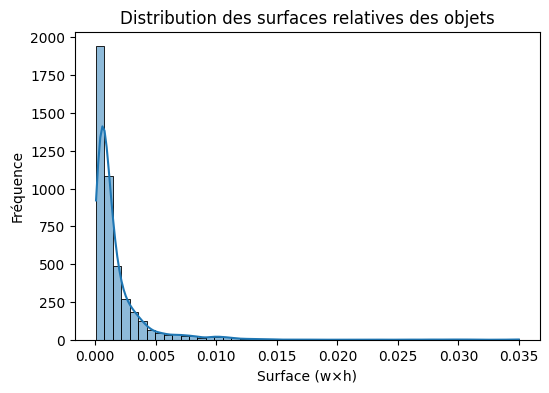

In [ ]:
df["area"] = df["width"] * df["height"]

plt.figure(figsize=(6,4))
sns.histplot(df["area"], bins=50, kde=True)
plt.title("Distribution des surfaces relatives des objets")
plt.xlabel("Surface (w×h)")
plt.ylabel("Fréquence")
plt.show()

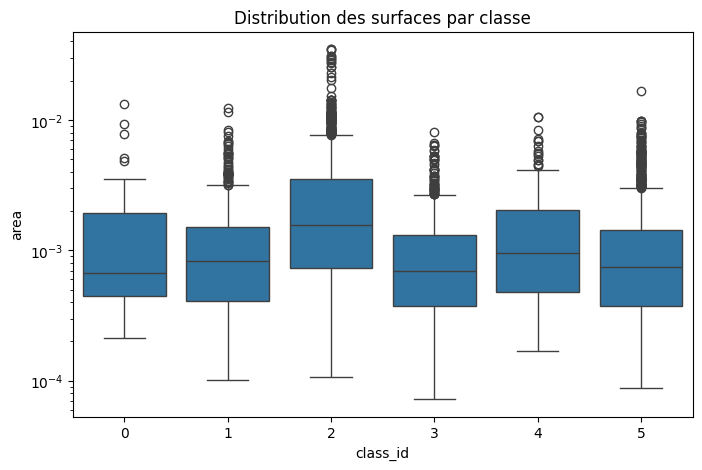

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(x="class_id", y="area", data=df)
plt.title("Distribution des surfaces par classe")
plt.yscale("log")  # si les tailles varient beaucoup
plt.show()
